In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Environment is ready!")

Environment is ready!


In [3]:
data_path = "../data/raw/Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv"

df = pd.read_csv(data_path)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (286467, 79)


In [4]:
# Show the first 5 rows
df.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,22,1266342,41,44,2664,6954,456,0,64.975610,109.864573,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,22,1319353,41,44,2664,6954,456,0,64.975610,109.864573,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,22,160,1,1,0,0,0,0,0.000000,0.000000,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,22,1303488,41,42,2728,6634,456,0,66.536585,110.129945,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,35396,77,1,2,0,0,0,0,0.000000,0.000000,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [5]:
# Clean column names
df.columns = df.columns.str.strip()

# Show all column names
for i, column in enumerate(df.columns, start=1):
    print(i, column)

1 Destination Port
2 Flow Duration
3 Total Fwd Packets
4 Total Backward Packets
5 Total Length of Fwd Packets
6 Total Length of Bwd Packets
7 Fwd Packet Length Max
8 Fwd Packet Length Min
9 Fwd Packet Length Mean
10 Fwd Packet Length Std
11 Bwd Packet Length Max
12 Bwd Packet Length Min
13 Bwd Packet Length Mean
14 Bwd Packet Length Std
15 Flow Bytes/s
16 Flow Packets/s
17 Flow IAT Mean
18 Flow IAT Std
19 Flow IAT Max
20 Flow IAT Min
21 Fwd IAT Total
22 Fwd IAT Mean
23 Fwd IAT Std
24 Fwd IAT Max
25 Fwd IAT Min
26 Bwd IAT Total
27 Bwd IAT Mean
28 Bwd IAT Std
29 Bwd IAT Max
30 Bwd IAT Min
31 Fwd PSH Flags
32 Bwd PSH Flags
33 Fwd URG Flags
34 Bwd URG Flags
35 Fwd Header Length
36 Bwd Header Length
37 Fwd Packets/s
38 Bwd Packets/s
39 Min Packet Length
40 Max Packet Length
41 Packet Length Mean
42 Packet Length Std
43 Packet Length Variance
44 FIN Flag Count
45 SYN Flag Count
46 RST Flag Count
47 PSH Flag Count
48 ACK Flag Count
49 URG Flag Count
50 CWE Flag Count
51 ECE Flag Count
52 Down

In [6]:
# Show the class labels and their counts
df["Label"].value_counts()

Label
PortScan    158930
BENIGN      127537
Name: count, dtype: int64

In [7]:
# Basic dataset information
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nMissing values:")
print(df.isnull().sum().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

Number of rows: 286467
Number of columns: 79

Missing values:
15

Duplicate rows:
72353


In [8]:
# Check data types
df.dtypes.value_counts()

int64      54
float64    24
str         1
Name: count, dtype: int64

In [9]:
# Check for infinity in numeric columns
numeric_df = df.select_dtypes(include=np.number)

print("Positive infinity:", np.isposinf(numeric_df).sum().sum())
print("Negative infinity:", np.isneginf(numeric_df).sum().sum())

Positive infinity: 727
Negative infinity: 0


In [10]:
# Missing values by column
missing = df.isnull().sum()
print(missing[missing > 0])

Flow Bytes/s    15
dtype: int64


In [11]:
# Infinity values by column
numeric_df = df.select_dtypes(include=np.number)

inf_counts = np.isinf(numeric_df).sum()
print(inf_counts[inf_counts > 0])

Flow Bytes/s      356
Flow Packets/s    371
dtype: int64


In [12]:
# Duplicate rows by class
duplicate_rows = df[df.duplicated(keep=False)]

print(duplicate_rows["Label"].value_counts())

Label
PortScan    101501
BENIGN        6203
Name: count, dtype: int64


In [ ]:
## Data Cleaning

The initial data-quality assessment identified missing and infinite values,
mainly in the `Flow Bytes/s` and `Flow Packets/s` features. Exact duplicate
rows were also present in the dataset.

For preprocessing, infinite values were converted to missing values, rows
containing missing values were removed, and exact duplicate rows were
dropped. The original DataFrame was preserved and the cleaned data was stored
separately.

In [13]:
# Create a copy before cleaning
df_clean = df.copy()

# Replace positive and negative infinity with NaN
df_clean.replace([np.inf, -np.inf], np.nan, inplace=True)

# Remove rows containing missing values
df_clean.dropna(inplace=True)

# Remove exact duplicate rows
df_clean.drop_duplicates(inplace=True)

# Reset the row index
df_clean.reset_index(drop=True, inplace=True)

print("Original shape:", df.shape)
print("Cleaned shape:", df_clean.shape)
print("Rows removed:", len(df) - len(df_clean))

Original shape: (286467, 79)
Cleaned shape: (213777, 79)
Rows removed: 72690


In [14]:
print("Missing values:", df_clean.isnull().sum().sum())

numeric_clean = df_clean.select_dtypes(include=np.number)

print("Infinite values:", np.isinf(numeric_clean).sum().sum())
print("Duplicate rows:", df_clean.duplicated().sum())

Missing values: 0
Infinite values: 0
Duplicate rows: 0


In [15]:
print("Before cleaning:")
print(df["Label"].value_counts())

print("\nAfter cleaning:")
print(df_clean["Label"].value_counts())

print("\nClass percentages after cleaning:")
print(
    df_clean["Label"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Before cleaning:
Label
PortScan    158930
BENIGN      127537
Name: count, dtype: int64

After cleaning:
Label
BENIGN      123083
PortScan     90694
Name: count, dtype: int64

Class percentages after cleaning:
Label
BENIGN      57.58
PortScan    42.42
Name: proportion, dtype: float64


## Exploratory Data Analysis

This section explores the distribution of network traffic classes and selected
flow-based features after data cleaning. The objective is to identify patterns
that may help distinguish benign traffic from PortScan activity.

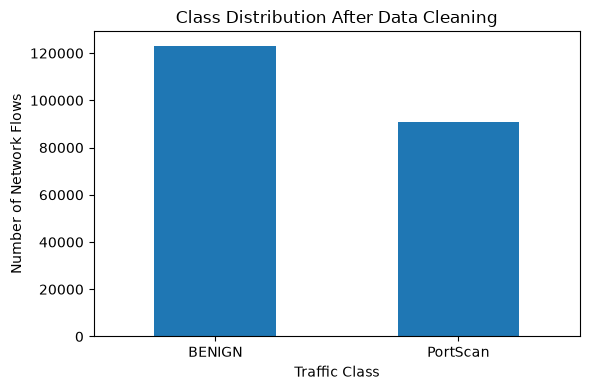

In [16]:
# Class distribution

class_counts = df_clean["Label"].value_counts()

plt.figure(figsize=(6, 4))
class_counts.plot(kind="bar")

plt.title("Class Distribution After Data Cleaning")
plt.xlabel("Traffic Class")
plt.ylabel("Number of Network Flows")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [17]:
# Encode the target temporarily for correlation analysis
df_analysis = df_clean.copy()
df_analysis["Target"] = df_analysis["Label"].map({
    "BENIGN": 0,
    "PortScan": 1
})

numeric_analysis = df_analysis.select_dtypes(include=np.number)

target_corr = (
    numeric_analysis
    .corr()["Target"]
    .drop("Target")
    .abs()
    .sort_values(ascending=False)
)

print("Top 10 features associated with the target:")
print(target_corr.head(10))

Top 10 features associated with the target:
PSH Flag Count            0.750133
Min Packet Length         0.494810
min_seg_size_forward      0.414397
Bwd Packet Length Min     0.402334
Average Packet Size       0.392307
Fwd Packet Length Min     0.384631
ACK Flag Count            0.370461
Packet Length Mean        0.367574
Bwd Packet Length Mean    0.341765
Avg Bwd Segment Size      0.341765
Name: Target, dtype: float64


In [18]:
# Compare selected features between BENIGN and PortScan
selected_features = [
    "PSH Flag Count",
    "Min Packet Length",
    "min_seg_size_forward"
]

print(
    df_clean.groupby("Label")[selected_features]
    .median()
    .round(2)
)

          PSH Flag Count  Min Packet Length  min_seg_size_forward
Label                                                            
BENIGN               0.0                6.0                  20.0
PortScan             1.0                0.0                  32.0


### Feature-Level Analysis

Correlation analysis identified several flow characteristics that are strongly
associated with the traffic class. In particular, `PSH Flag Count` showed the
strongest absolute linear association with the target. Selected features are
examined below to better understand how their distributions differ between
benign and PortScan traffic.

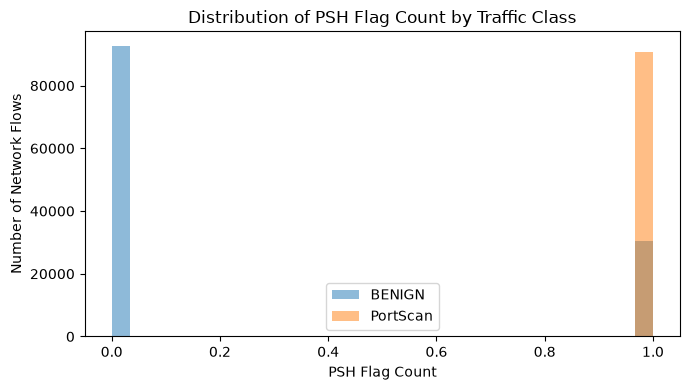

In [19]:
# Distribution of PSH Flag Count by traffic class

plt.figure(figsize=(7, 4))

for label in ["BENIGN", "PortScan"]:
    values = df_clean.loc[df_clean["Label"] == label, "PSH Flag Count"]

    plt.hist(
        values,
        bins=30,
        alpha=0.5,
        label=label
    )

plt.title("Distribution of PSH Flag Count by Traffic Class")
plt.xlabel("PSH Flag Count")
plt.ylabel("Number of Network Flows")
plt.legend()
plt.tight_layout()
plt.show()

In [20]:
# Cross-tabulation of PSH Flag Count and traffic class
psh_table = pd.crosstab(
    df_clean["PSH Flag Count"],
    df_clean["Label"],
    normalize="columns"
) * 100

print(psh_table.round(2))

Label           BENIGN  PortScan
PSH Flag Count                  
0                 75.3      0.07
1                 24.7     99.93


In [21]:
# Check unique values of the strongest features
for feature in [
    "PSH Flag Count",
    "Min Packet Length",
    "min_seg_size_forward"
]:
    print(f"\n{feature}")
    print("Number of unique values:", df_clean[feature].nunique())
    print("Sample values:", sorted(df_clean[feature].unique())[:20])


PSH Flag Count
Number of unique values: 2
Sample values: [np.int64(0), np.int64(1)]

Min Packet Length
Number of unique values: 107
Sample values: [np.int64(0), np.int64(2), np.int64(6), np.int64(18), np.int64(19), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36)]

min_seg_size_forward
Number of unique values: 11
Sample values: [np.int64(0), np.int64(6), np.int64(20), np.int64(24), np.int64(28), np.int64(32), np.int64(40), np.int64(44), np.int64(48), np.int64(52), np.int64(60)]


## EDA Summary

After preprocessing, the dataset contained 213,777 unique and valid network
flows, with 57.58% benign traffic and 42.42% PortScan traffic.

Exploratory analysis revealed clear differences between the two traffic
classes. `PSH Flag Count` showed the strongest absolute linear association
with the target among the examined numerical features. Nearly all PortScan
flows had a PSH Flag Count of 1, while benign traffic exhibited both 0 and 1.

These observations suggest that flow-level characteristics contain useful
information for distinguishing PortScan activity from benign network traffic.
However, these patterns are specific to the analyzed CICIDS2017 subset and
should not be interpreted as evidence of generalization to other attacks or
network environments.

In [22]:
from pathlib import Path

processed_dir = Path("../data/processed")
processed_dir.mkdir(parents=True, exist_ok=True)

output_path = processed_dir / "portscan_clean.csv"

df_clean.to_csv(output_path, index=False)

print("Saved to:", output_path)
print("Shape:", df_clean.shape)

Saved to: ..\data\processed\portscan_clean.csv
Shape: (213777, 79)
